# Step 1: Import libraries / Load the dataset

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://github.com/tanishq21/Mall-Customers/raw/main/Mall_Customers.csv"
df = pd.read_csv(url)

# Save the CSV file locally
df.to_csv("mall_customers.csv", index=False)
print("✅ File saved as mall_customers.csv")

✅ File saved as mall_customers.csv


Basic exploration

In [18]:
print("🔹 First 5 Rows:\n", df.head())
print("\n🔹 Dataset Info:\n")
print(df.info())
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Summary Statistics:\n", df.describe())

🔹 First 5 Rows:
    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

🔹 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

🔹 Missing Value

Data cleaning

In [19]:
df['Gender'] = df['Genre'].map({'Male': 1, 'Female': 0})
df = df.drop(columns=['CustomerID'])

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Genre                   200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
 4   Gender                  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


# Visual Exploration

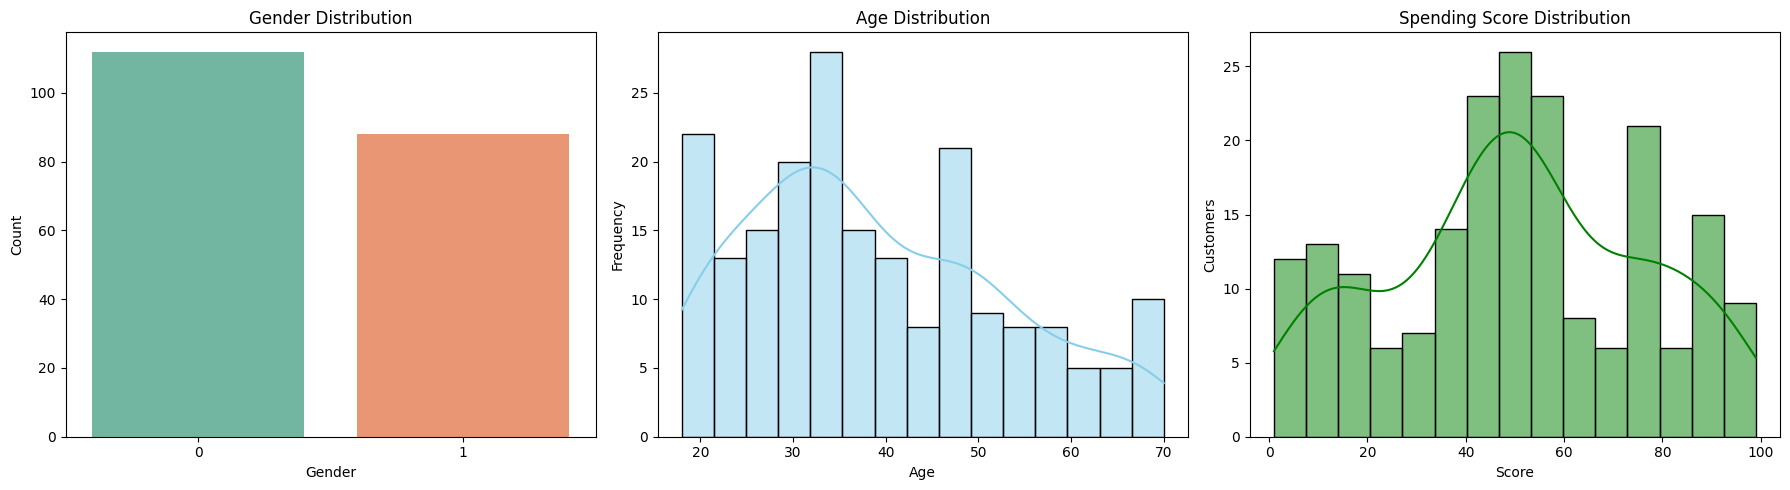

In [31]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Gender Distribution ---
sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

# --- Plot 2: Age Distribution ---
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Frequency")

# --- Plot 3: Spending Score Distribution ---
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, color='green', ax=axes[2])
axes[2].set_title("Spending Score Distribution")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.show()

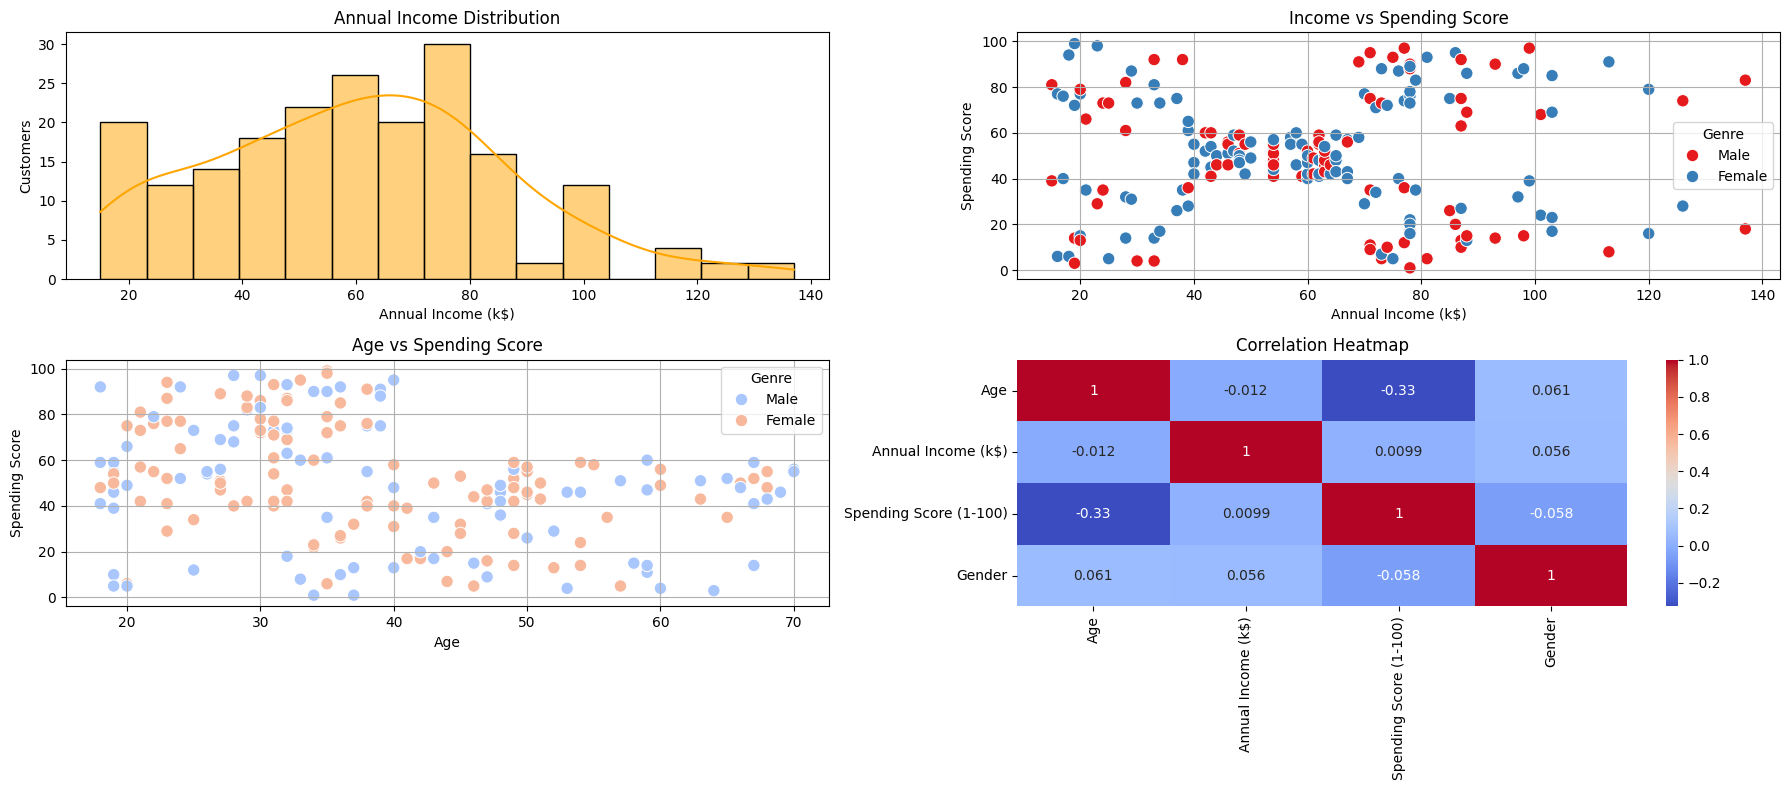

In [37]:

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# --- Plot 1: Income Distribution ---
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, color='orange', ax=axes[0, 0])
axes[0, 0].set_title("Annual Income Distribution")
axes[0, 0].set_xlabel("Annual Income (k$)")
axes[0, 0].set_ylabel("Customers")

# --- Plot 2: Income vs Spending Score ---
sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    data=df, hue='Genre', palette='Set1', s=80, ax=axes[0, 1]
)
axes[0, 1].set_title("Income vs Spending Score")
axes[0, 1].set_xlabel("Annual Income (k$)")
axes[0, 1].set_ylabel("Spending Score")
axes[0, 1].grid(True)

# --- Plot 3: Age vs Spending Score ---
sns.scatterplot(
    x='Age', y='Spending Score (1-100)',
    data=df, hue='Genre', palette='coolwarm', s=80, ax=axes[1, 0]
)
axes[1, 0].set_title("Age vs Spending Score")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Spending Score")
axes[1, 0].grid(True)

# --- Plot 4: Correlation Heatmap (Drop non-numeric columns) ---
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [39]:
# Create manual segments based on visual logic
def segment(row):
    if row['Annual Income (k$)'] >= 70 and row['Spending Score (1-100)'] >= 60:
        return 'VIP'
    elif row['Annual Income (k$)'] >= 70 and row['Spending Score (1-100)'] < 40:
        return 'Cautious Rich'
    elif row['Annual Income (k$)'] <= 40 and row['Spending Score (1-100)'] >= 60:
        return 'Young Spenders'
    elif row['Annual Income (k$)'] <= 40 and row['Spending Score (1-100)'] <= 40:
        return 'Low Budget'
    else:
        return 'Average'
    
    # Apply manual segmentation
df['Manual_Segment'] = df.apply(segment, axis=1)

# Show segment counts
print("📊 Manual Segment Counts:\n", df['Manual_Segment'].value_counts())


📊 Manual Segment Counts:
 Manual_Segment
Average           79
VIP               38
Cautious Rich     37
Low Budget        23
Young Spenders    23
Name: count, dtype: int64


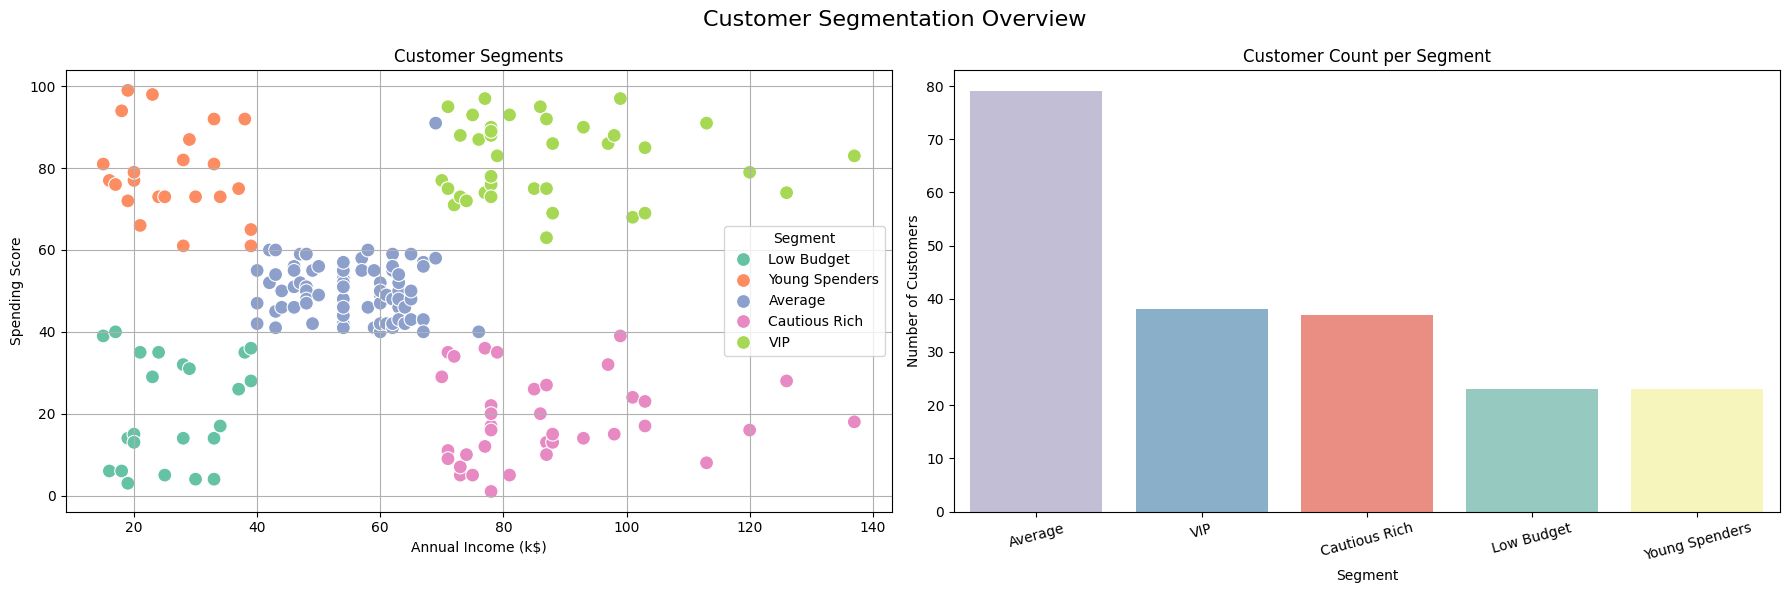

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Customer Segments ---
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Manual_Segment',
    data=df,
    palette='Set2',
    s=100,
    ax=axes[0]
)
axes[0].set_title("Customer Segments")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score")
axes[0].legend(title='Segment', loc='best')
axes[0].grid(True)

# --- Plot 2: Segment Counts ---
sns.countplot(
    data=df,
    x='Manual_Segment',
    hue='Manual_Segment',  # Added to avoid FutureWarning
    palette='Set3',
    order=df['Manual_Segment'].value_counts().index,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Customer Count per Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis='x', rotation=15)

# Optional: Unified title
fig.suptitle("Customer Segmentation Overview", fontsize=16)

# Final layout
plt.tight_layout()
plt.show()

In [44]:
print("\n" + "="*70)
print("✅ Customer Segmentation Analysis Project - Completed Successfully!")
print("📁 Output includes:")
print("   - Cleaned and explored dataset")
print("   - Manual customer segmentation based on income & spending")
print("   - Visual segment insights and business grouping")
print("   - README.md and documentation ready")
print("="*70)



✅ Customer Segmentation Analysis Project - Completed Successfully!
📁 Output includes:
   - Cleaned and explored dataset
   - Manual customer segmentation based on income & spending
   - Visual segment insights and business grouping
   - README.md and documentation ready
